# [5.0] DESI DR1 x LSST DP2 Pilot Data

In this notebook, we will:
- **move the catalog** at NERSC to provide a public endpoint of our DESI DR1 catalog
- **crossmatch** the NERSC-hosted DESI DR1 catalog with the LSST DP2 Pilot Data at USDF
- **save** the resulting catalog on USDF
- discuss **performance and resource use** of the crossmatch

## Pre-set up: move catalog to public NERSC dir

In the shell, I ran:
```bash
mv /global/cfs/cdirs/cosmo/users/olynn/desi-dr1-main-dark \
   /global/cfs/cdirs/cosmo/www/users/olynn/desi-dr1-main-dark
```

And to make it readable:
```bash
chmod o+rX -R /global/cfs/cdirs/cosmo/www/users/olynn/
```
But also:
```bash
chmod o+rX /global/cfs/cdirs/cosmo/www/users/olynn
```

## Set up

In [1]:
import lsdb
from dask.distributed import Client

In [2]:
!lscpu | grep -E "^CPU\(s\)|Thread|Core|Socket"

CPU(s):              128
Thread(s) per core:  2
Core(s) per socket:  64
Socket(s):           1
Model name:          AMD EPYC 7713P 64-Core Processor


In [3]:
# Make a dask client

client = Client(
    n_workers=8,
    memory_limit="auto"
)

## Load catalogs (note - Neven wanted us to start with a DP1 demo, then do DP2)

### Load DESI

In [4]:
desi_cat = lsdb.open_catalog("https://portal.nersc.gov/project/cosmo/users/olynn/desi-dr1-main-dark/")
desi_cat

,TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,spectra_b,spectra_r,spectra_z
npartitions=5769,,,,,,,,
"Order: 6, Pixel: 0",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],"nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv..."
"Order: 6, Pixel: 1",...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12286",...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12287",...,...,...,...,...,...,...,...


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of desi-dr1-main-dark'}>)

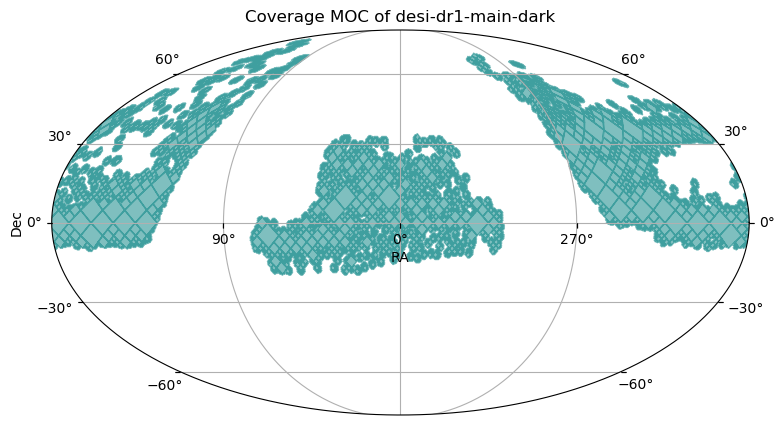

In [7]:
desi_cat.plot_coverage()

### Load DP1

In [8]:
dp1_cat = lsdb.open_catalog("/sdf/data/rubin/shared/lsdb_commissioning/hats/v29_0_0/dia_object_collection")
dp1_cat

,dec,diaObjectId,nDiaSources,ra,radecMjdTai,tract,diaObjectForcedSource,diaSource
npartitions=208,,,,,,,,
"Order: 6, Pixel: 130",double[pyarrow],int64[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],int64[pyarrow],"nested<band: [string], coord_dec: [double], co...","nested<band: [string], centroid_flag: [bool], ..."
"Order: 6, Pixel: 136",...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
"Order: 11, Pixel: 36833621",...,...,...,...,...,...,...,...
"Order: 7, Pixel: 143884",...,...,...,...,...,...,...,...


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of dia_object_lc'}>)

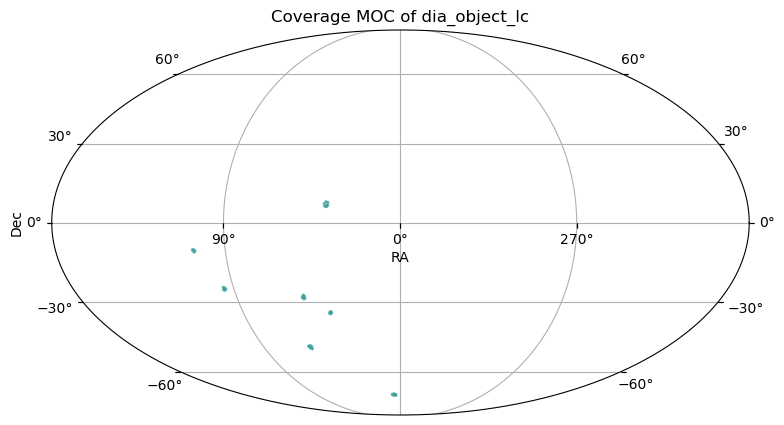

In [9]:
dp1_cat.plot_coverage()

### Load DP2 Pilot

In [15]:
dp2_cat = lsdb.open_catalog('/sdf/data/rubin/shared/lsdb_commissioning/hats/v30_0_4/dia_object_collection')
dp2_cat

,dec,diaObjectId,nDiaSources,ra,tract,diaObjectForcedSource,diaSource
npartitions=275,,,,,,,
"Order: 11, Pixel: 27868754",double[pyarrow],int64[pyarrow],int64[pyarrow],double[pyarrow],int64[pyarrow],"nested<band: [string], coord_dec: [double], co...","nested<band: [string], centroid_flag: [bool], ..."
"Order: 6, Pixel: 27226",...,...,...,...,...,...,...
...,...,...,...,...,...,...,...
"Order: 8, Pixel: 550144",...,...,...,...,...,...,...
"Order: 11, Pixel: 35225601",...,...,...,...,...,...,...


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of dia_object_lc'}>)

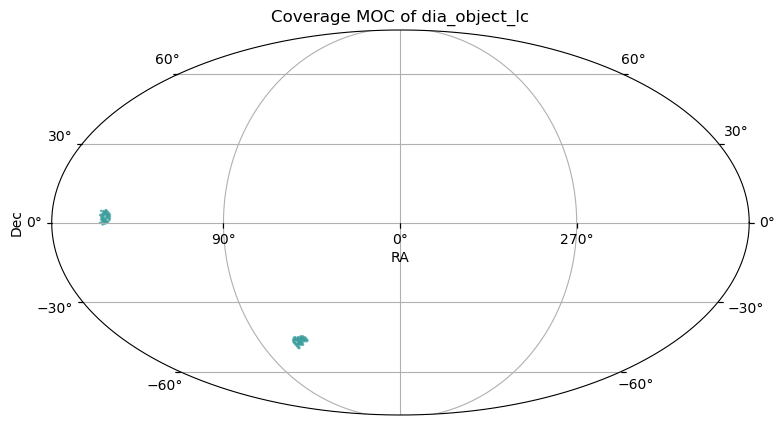

In [16]:
dp2_cat.plot_coverage()

## Do crossmatches

### DESI x LSST DP1

In [10]:
desi_x_dp1 = desi_cat.crossmatch(dp1_cat)

/sdf/home/o/olynn/.local/lib/python3.13/site-packages/lsdb/catalog/catalog.py:358: FutureWarning: The default suffix behavior will change from applying suffixes to all columns to only applying suffixes to overlapping columns in a future release.To maintain the current behavior, explicitly set `suffix_method='all_columns'`. To change to the new behavior, set `suffix_method='overlapping_columns'`.
  warnings.warn(


In [11]:
desi_x_dp1

,TARGETID_desi-dr1-main-dark,TARGET_RA_desi-dr1-main-dark,TARGET_DEC_desi-dr1-main-dark,Z_desi-dr1-main-dark,ZERR_desi-dr1-main-dark,spectra_b_desi-dr1-main-dark,spectra_r_desi-dr1-main-dark,spectra_z_desi-dr1-main-dark,dec_dia_object_lc,diaObjectId_dia_object_lc,nDiaSources_dia_object_lc,ra_dia_object_lc,radecMjdTai_dia_object_lc,tract_dia_object_lc,diaObjectForcedSource_dia_object_lc,diaSource_dia_object_lc,_dist_arcsec
npartitions=9,,,,,,,,,,,,,,,,,
"Order: 6, Pixel: 130",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],"nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...",double[pyarrow],int64[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],int64[pyarrow],"nested<band: [string], coord_dec: [double], co...","nested<band: [string], centroid_flag: [bool], ...",double[pyarrow]
"Order: 6, Pixel: 136",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 17885",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 17887",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of desi-dr1-main-dark_x_dia_object_lc'}>)

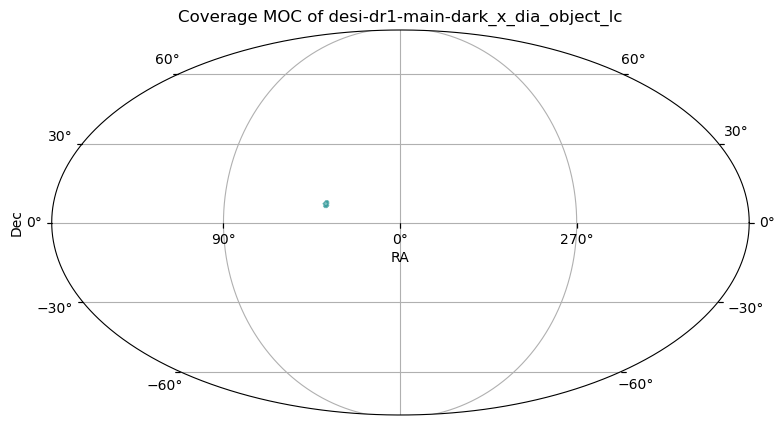

In [13]:
desi_x_dp1.plot_coverage()

### DESI x LSST DP2 Pilot

In [17]:
desi_x_dp2 = desi_cat.crossmatch(dp2_cat)

/sdf/home/o/olynn/.local/lib/python3.13/site-packages/lsdb/catalog/catalog.py:358: FutureWarning: The default suffix behavior will change from applying suffixes to all columns to only applying suffixes to overlapping columns in a future release.To maintain the current behavior, explicitly set `suffix_method='all_columns'`. To change to the new behavior, set `suffix_method='overlapping_columns'`.
  warnings.warn(


In [18]:
desi_x_dp2

,TARGETID_desi-dr1-main-dark,TARGET_RA_desi-dr1-main-dark,TARGET_DEC_desi-dr1-main-dark,Z_desi-dr1-main-dark,ZERR_desi-dr1-main-dark,spectra_b_desi-dr1-main-dark,spectra_r_desi-dr1-main-dark,spectra_z_desi-dr1-main-dark,dec_dia_object_lc,diaObjectId_dia_object_lc,nDiaSources_dia_object_lc,ra_dia_object_lc,tract_dia_object_lc,diaObjectForcedSource_dia_object_lc,diaSource_dia_object_lc,_dist_arcsec
npartitions=253,,,,,,,,,,,,,,,,
"Order: 11, Pixel: 27868754",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],"nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...",double[pyarrow],int64[pyarrow],int64[pyarrow],double[pyarrow],int64[pyarrow],"nested<band: [string], coord_dec: [double], co...","nested<band: [string], centroid_flag: [bool], ...",double[pyarrow]
"Order: 6, Pixel: 27226",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 27350",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 11, Pixel: 28092509",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of desi-dr1-main-dark_x_dia_object_lc'}>)

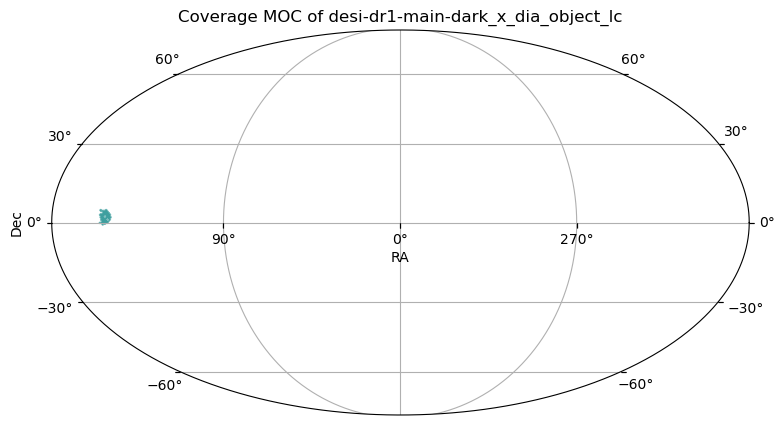

In [19]:
desi_x_dp2.plot_coverage()

## Verify crossmatched catalog

In [20]:
# Considering skipping, because the DP2 coverage is so small

## Performance analysis

In [ ]:
# Also might not be worth doing at this point?